<a href="https://colab.research.google.com/github/vansh-virmani/NextGenAI/blob/main/Feed_forward%20%26%26%20Backpropogation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [2]:
x=np.array([[1,0,1,0], [1,0,1,1], [0,1,0,1] ])
y=np.array([[1],[1],[0]])


In [3]:
def sigmoid(x):
  return 1/(1+np.exp(-x))


In [4]:
inputNeurons= x.shape[1] ## columns x1 x2 x3 x4 4cols 3rows
HiddenNeurons=3
outputNeurons=1
#hidden we can take by ourselves

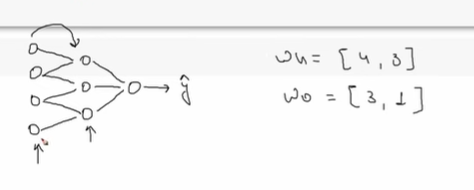

In [5]:
# weight for input neurons to hidden layer each neuron give- 3 weights
# ...                   hidden->output  .
# ...                                   .
# ...                                   . 3x1
# ... 4x3 matrix

In [6]:
# similarly bias for hidden= [1x3]  and for output-> [1x1]

In [7]:
weightHidden=np.random.uniform(size=(inputNeurons,HiddenNeurons))
biasHidden=np.random.uniform(size=(1,HiddenNeurons))
weightOutput=np.random.uniform(size=(HiddenNeurons,outputNeurons))
biasOutput=np.random.uniform(size=(1,outputNeurons))

In [8]:
 ## FeedForward
#  step1- apply dot product and add bias
fx= np.dot(x,weightHidden) +biasHidden

In [9]:
## step2- apply activation function
hiddenLayer=sigmoid(fx)

In [10]:
## step 3 - apply dot product and add bias : f(x)= hiddenLayer.weightOutput+ biasoutput
fx_=np.dot(hiddenLayer,weightOutput)+biasOutput



In [11]:
fx_


array([[2.2749276 ],
       [2.52216586],
       [2.4904448 ]])

In [12]:
biasHidden

array([[0.69443004, 0.46651449, 0.5818427 ]])

In [13]:
## step4 - activation on fx_
outputLayer=sigmoid(fx_)

In [14]:
outputLayer

array([[0.90677916],
       [0.92568119],
       [0.92346924]])

In [15]:
## y_pred is 1 1 0 not matching correctly

**Back-propogation**

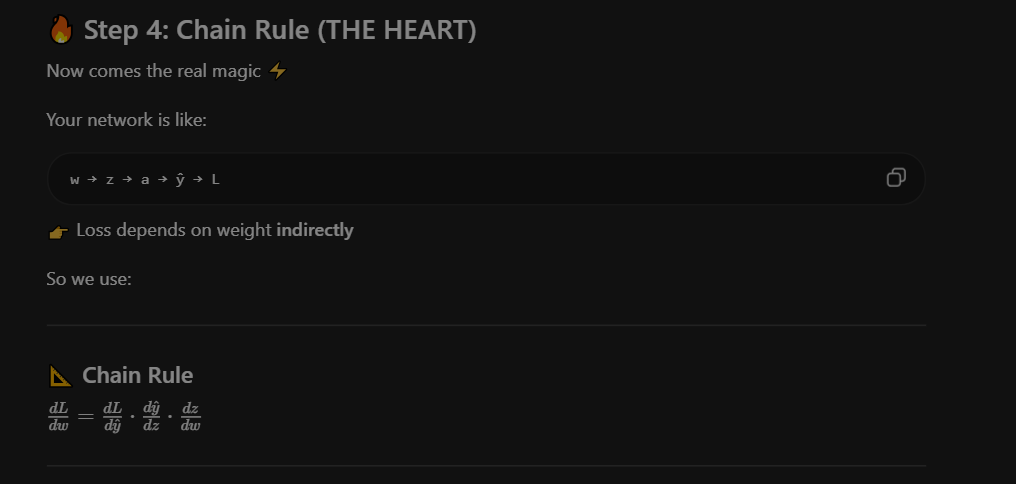

In [16]:
# backprop is mainly for if errors or loss then go back to hidden and input layer to correct and change weights
# CHANGE IN WEIGHTS-> CHANGES Z-> CHANGES PREDICTJON-> CHANGE IN LOSS



In [17]:
#3steps- loss ,slope,delta for hidden layer and output layer

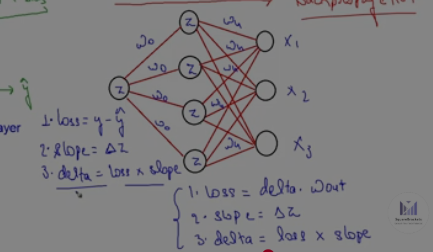

In [18]:
def derivativesigmoid(x):
  return (x)*(1-x)

In [19]:
ErrorOutput=outputLayer-y # error on output layer
# slope on output layer -derivatie of activation fn
slopeOutput=derivativesigmoid(outputLayer)
#Delta=error*slope to final check how much error this neuron cause what effect
deltaOutput = ErrorOutput * slopeOutput
#WE CAN'T ALWAYS  use chain rule multople tiems so we calc delta another method


In [21]:
ErrorHidden=np.dot(deltaOutput,weightOutput.T)
slopeHidden=derivativesigmoid(hiddenLayer)
deltaHidden=ErrorHidden*slopeHidden



In [22]:
ErrorOutput

array([[-0.09322084],
       [-0.07431881],
       [ 0.92346924]])

In [23]:
# weight and bias update
alpha=0.01
weightOutput=weightOutput-hiddenLayer.T.dot(deltaOutput) *alpha

hiddenLayer.T.dot(deltaOutput) *alpha this is loss as **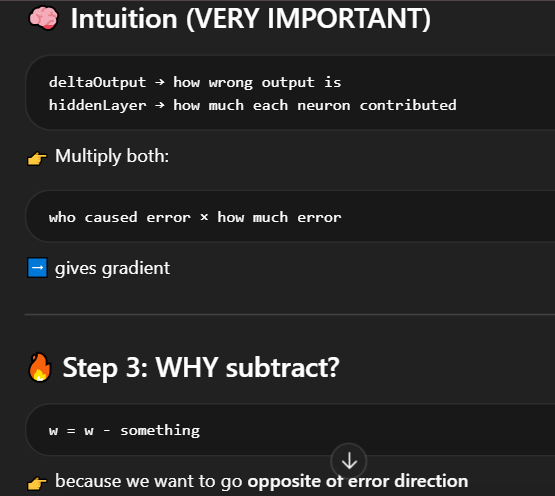**

In [27]:
weightHidden=weightHidden-x.T.dot(deltaHidden)*alpha
# input->hidden weight update always uses wieghts of the layer before it the input layer
biasOutput=biasOutput-np.sum(deltaOutput)*alpha
biasHidden=biasHidden-np.sum(deltaHidden)*alpha

In [36]:
#we must train it and put underloop jab taka optimize nhi hota
weightHidden=np.random.uniform(size=(inputNeurons,HiddenNeurons))
biasHidden=np.random.uniform(size=(1,HiddenNeurons))
weightOutput=np.random.uniform(size=(HiddenNeurons,outputNeurons))
biasOutput=np.random.uniform(size=(1,outputNeurons))

In [37]:

epochs=30000
alpha=0.01
for i in range(epochs):
    ## FeedForward
    #  step1- apply dot product and add bias
    fx= np.dot(x,weightHidden) +biasHidden
    ## step2- apply activation function
    hiddenLayer=sigmoid(fx)
    ## step 3 - apply dot product and add bias : f(x)= hiddenLayer.weightOutput+ biasoutput
    fx_=np.dot(hiddenLayer,weightOutput)+biasOutput
    ## step4 - activation on fx_
    outputLayer=sigmoid(fx_)


    ErrorOutput=outputLayer-y # error on output layer
    # slope on output layer -derivatie of activation fn
    slopeOutput=derivativesigmoid(outputLayer)
    #Delta=error*slope to final check how much error this neuron cause what effect
    deltaOutput = ErrorOutput * slopeOutput
    #WE CAN'T ALWAYS  use chain rule multople tiems so we calc delta another method

    ErrorHidden=np.dot(deltaOutput,weightOutput.T)
    slopeHidden=derivativesigmoid(hiddenLayer)
    deltaHidden=ErrorHidden*slopeHidden

    # weight and bias update
    alpha=0.01
    weightOutput=weightOutput-hiddenLayer.T.dot(deltaOutput) *alpha
    weightHidden=weightHidden-x.T.dot(deltaHidden)*alpha
    # input->hidden weight update always uses wieghts of the layer before it the input layer
    biasOutput=biasOutput-np.sum(deltaOutput)*alpha
    biasHidden=biasHidden-np.sum(deltaHidden)*alpha




In [38]:
outputLayer

array([[0.97157694],
       [0.95581181],
       [0.05378773]])

In [ ]:
#output-> 1 ,1, 0 same as y